In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

In [3]:
df['species'] = df['species'].map(dict(enumerate(iris.target_names)))

In [4]:
print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [6]:
print("\nFeature Data Types:\n")
print(df.dtypes)

print("\nFeature Classification:")
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col} --> Nominal (Categorical)")
    else:
        print(f"{col} --> Numeric (Continuous)")


Feature Data Types:

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Feature Classification:
sepal length (cm) --> Numeric (Continuous)
sepal width (cm) --> Numeric (Continuous)
petal length (cm) --> Numeric (Continuous)
petal width (cm) --> Numeric (Continuous)
species --> Nominal (Categorical)


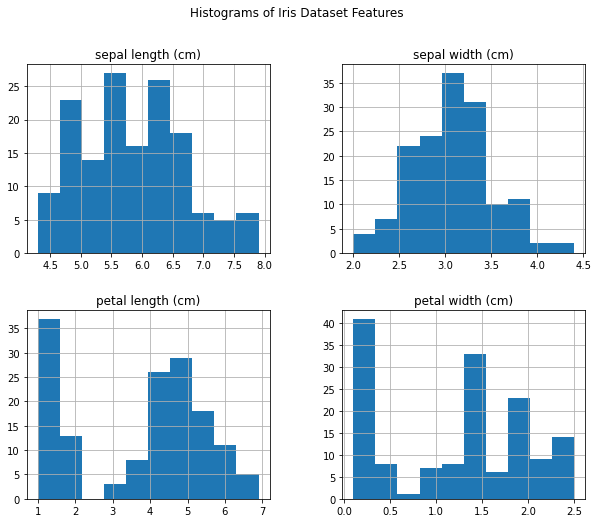

In [7]:
df.hist(figsize=(10, 8))
plt.suptitle("Histograms of Iris Dataset Features")
plt.show()

In [9]:
print("\nOutlier Detection using IQR method:\n")

for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")


Outlier Detection using IQR method:

sepal length (cm): 0 outliers
sepal width (cm): 4 outliers
petal length (cm): 0 outliers
petal width (cm): 0 outliers
